# Customer Segmentation: K-Means and GMM


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

In [33]:
# Load dataset
csv_path = "Dataset/Mall_Customers.csv"
df = pd.read_csv(csv_path)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [34]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [35]:
k_values = np.arange(2, 11)
kmeans_inertias = []
kmeans_silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    kmeans_inertias.append(km.inertia_)
    kmeans_silhouettes.append(silhouette_score(X_scaled, labels))


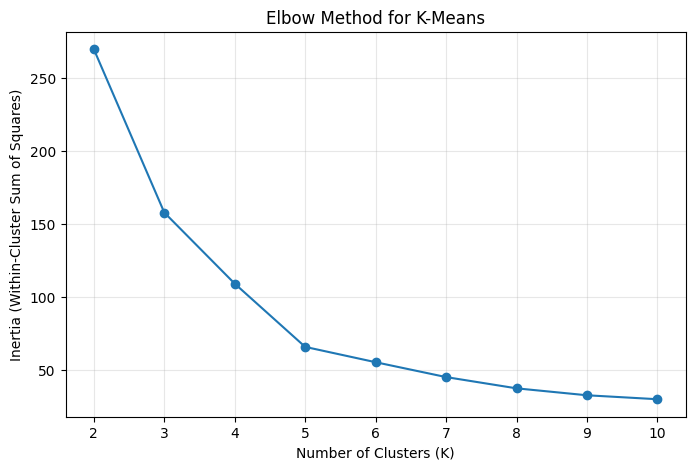

In [36]:
# Elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, kmeans_inertias, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.grid(alpha=0.3)
plt.show()

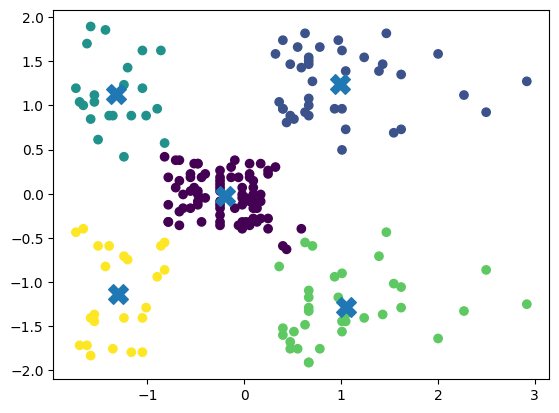

Silhouette: 0.5546571631111091
K-Means Inertia: 65.57
K-Means Silhouette: 0.5547


In [37]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = labels_kmeans
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_kmeans)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=200, marker='X')
plt.show()
print('Silhouette:', silhouette_score(X_scaled, labels_kmeans))

print(f"K-Means Inertia: {kmeans.inertia_:.2f}")
print(f"K-Means Silhouette: {silhouette_score(X_scaled, labels_kmeans):.4f}")

In [38]:
kmeans_summary = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
kmeans_summary

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


In [ ]:
gmm_log_likelihood = []
gmm_aic = []
gmm_bic = []
gmm_silhouettes = []

for k in k_values:
    gmm_tmp = GaussianMixture(n_components=k, random_state=42, covariance_type="full")
    gmm_tmp.fit(X_scaled)
    labels_tmp = gmm_tmp.predict(X_scaled)

    gmm_log_likelihood.append(gmm_tmp.score(X_scaled))
    gmm_aic.append(gmm_tmp.aic(X_scaled))
    gmm_bic.append(gmm_tmp.bic(X_scaled))
    gmm_silhouettes.append(silhouette_score(X_scaled, labels_tmp))

best_gmm_k = int(k_values[np.argmin(gmm_bic)])
print("Best components by BIC:", best_gmm_k)

Best components by BIC: 5


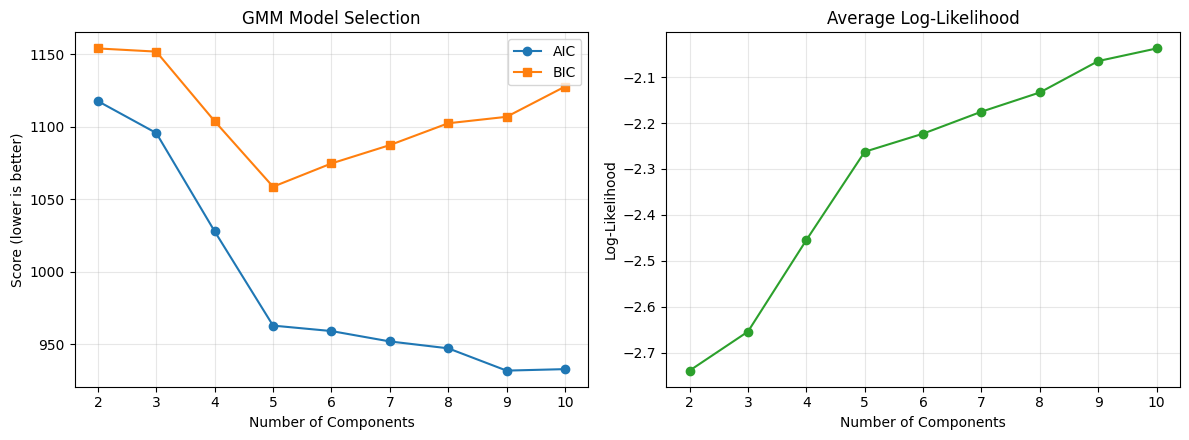

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(k_values, gmm_aic, marker="o", label="AIC")
ax[0].plot(k_values, gmm_bic, marker="s", label="BIC")
ax[0].set_title("GMM Model Selection")
ax[0].set_xlabel("Number of Components")
ax[0].set_ylabel("Score (lower is better)")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(k_values, gmm_log_likelihood, marker="o", color="tab:green")
ax[1].set_title("Average Log-Likelihood")
ax[1].set_xlabel("Number of Components")
ax[1].set_ylabel("Log-Likelihood")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
gmm = GaussianMixture(n_components=best_gmm_k, random_state=42, covariance_type="full")
gmm.fit(X_scaled)

gmm_prob = gmm.predict_proba(X_scaled)
df["GMM_Cluster"] = np.argmax(gmm_prob, axis=1)

print(f"GMM Log-Likelihood: {gmm.score(X_scaled):.4f}")
print(f"GMM AIC: {gmm.aic(X_scaled):.2f}")
print(f"GMM BIC: {gmm.bic(X_scaled):.2f}")
print(f"GMM Silhouette: {silhouette_score(X_scaled, df['GMM_Cluster']):.4f}")

GMM Log-Likelihood: -2.2625
GMM AIC: 963.00
GMM BIC: 1058.65
GMM Silhouette: 0.5537


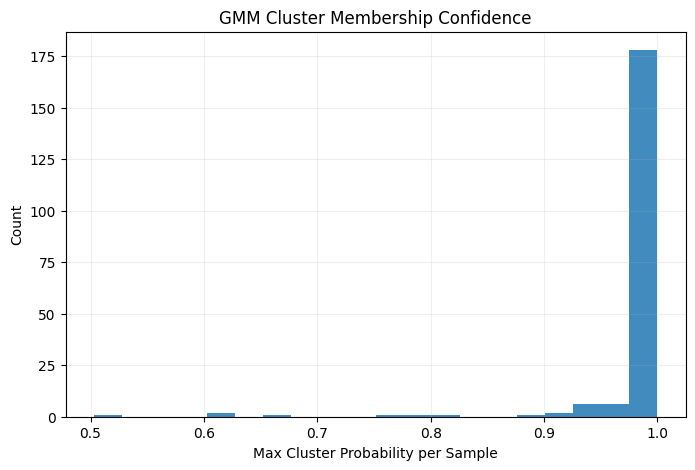

In [ ]:
max_prob = gmm_prob.max(axis=1)

plt.figure(figsize=(8, 5))
plt.hist(max_prob, bins=20, color="tab:blue", alpha=0.85)
plt.title("GMM Cluster Membership Confidence")
plt.xlabel("Max Cluster Probability per Sample")
plt.ylabel("Count")
plt.grid(alpha=0.2)
plt.show()

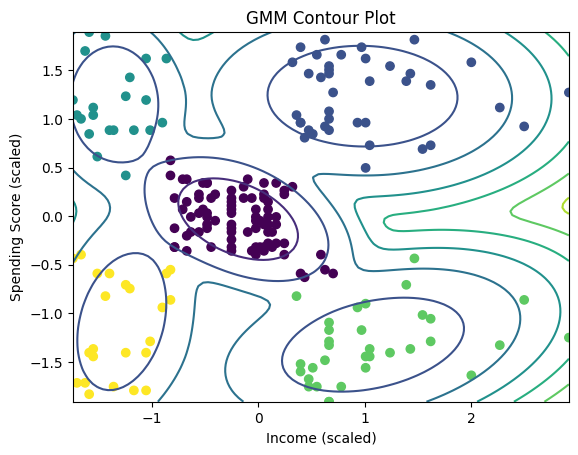

In [ ]:
x = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 100)
y = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)
grid = np.array([X_grid.ravel(), Y_grid.ravel()]).T

# log likelihood
Z = -gmm.score_samples(grid)
Z = Z.reshape(X_grid.shape)
plt.figure()
plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df["GMM_Cluster"])
plt.title("GMM Contour Plot")
plt.xlabel("Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()


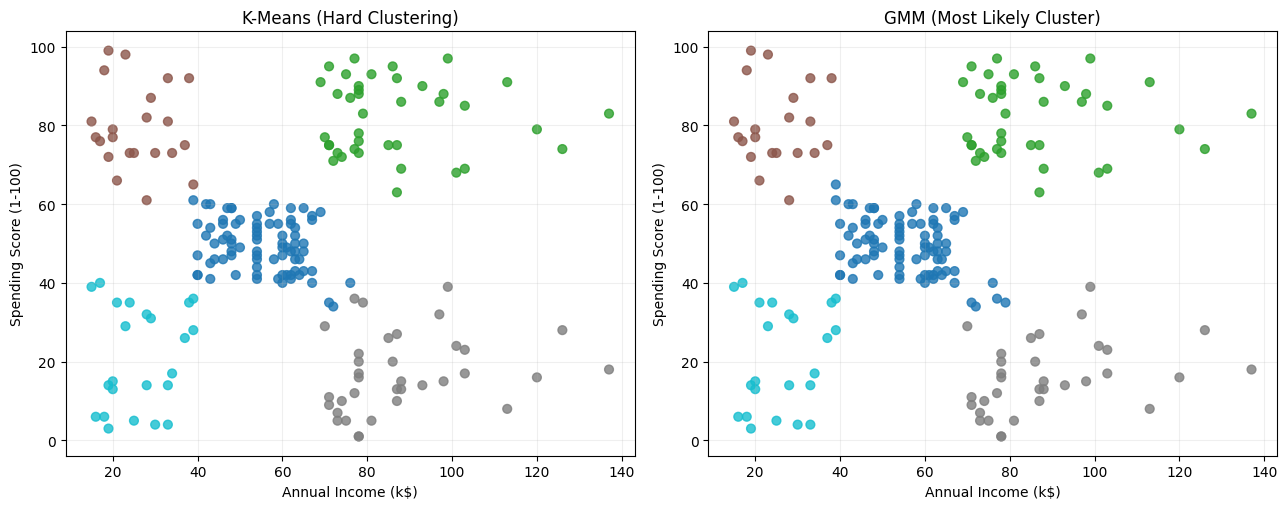

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))

ax[0].scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["KMeans_Cluster"],
    cmap="tab10",
    s=40,
    alpha=0.8,
)
ax[0].set_title("K-Means (Hard Clustering)")
ax[0].set_xlabel("Annual Income (k$)")
ax[0].set_ylabel("Spending Score (1-100)")
ax[0].grid(alpha=0.2)

ax[1].scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["GMM_Cluster"],
    cmap="tab10",
    s=40,
    alpha=0.8,
)
ax[1].set_title("GMM (Most Likely Cluster)")
ax[1].set_xlabel("Annual Income (k$)")
ax[1].set_ylabel("Spending Score (1-100)")
ax[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()